In [1]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from deepthinking.models import dt_net_recall_2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load('./outputs/mazes_ablation/training-rusty-Tayla/model_best.pth', map_location=device)

state_dict = checkpoint['net']

/tmp/ipykernel_623530/2053517538.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('./outputs/mazes_ablation/training-rusty-Tayla/model_best.pth', 

In [3]:
model = dt_net_recall_2d(width=128, in_channels=3)

# --- FIX: Strip the "module." prefix ---
from collections import OrderedDict
new_state_dict = OrderedDict()
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k # remove `module.`
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)
model.to(device)
model.eval()

DTNet(
  (projection): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU()
  )
  (recur_block): Sequential(
    (0): Conv2d(131, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Sequential(
      (0): BasicBlock2D(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn1): Sequential()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn2): Sequential()
        (shortcut): Sequential()
      )
      (1): BasicBlock2D(
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn1): Sequential()
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (gn2): Sequential()
        (shortcut): Sequential()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(128, 32, kernel_size=(3, 3), stride=(1,

In [4]:
from easy_to_hard_data import MazeDataset
testset = MazeDataset("data", train=False, size=9, download=False)

Loading mazes of size 9 x 9.


In [5]:
alpha_list = [0.5, 1, 2, 10, 100]
losses = {alpha: [] for alpha in alpha_list}
for alpha in alpha_list:
    x = testset[:30][0].permute(0,3,1,2).to(device)
    x_5 = torch.relu(model.projection(x)).to(device)
    max_iters = 100

    for it in range(max_iters):
        x_1 = model.recur_block[0](torch.cat([x_5, x], dim=1)).to(device)
        conv_x1 = model.recur_block[1][0].conv1(x_1).to(device)
        x_21 = torch.relu(conv_x1).to(device)
        conv_x21 = model.recur_block[1][0].conv2(x_21).to(device)
        x_3 = torch.relu(conv_x21 + x_1).to(device)
        conv_x3 = model.recur_block[1][1].conv1(x_3).to(device)
        x_41 = torch.relu(conv_x3).to(device)
        conv_x41 = model.recur_block[1][1].conv2(x_41).to(device)
        x_5 = torch.relu(conv_x41 + x_3).to(device)
        loss = (- alpha / 2 * (torch.norm(torch.relu(-x_21 + 1/alpha * (-conv_x1 + x_21)), p=2, dim=(1, 2, 3))**2
                            + torch.norm(torch.relu(-x_3 + 1/alpha * (-conv_x21 - x_1 + x_3)), p=2, dim=(1, 2, 3))**2
                            + torch.norm(torch.relu(-x_41 + 1/alpha * (-conv_x3 + x_41)), p=2, dim=(1, 2, 3))**2
                            + torch.norm(torch.relu(-x_5 + 1/alpha * (-conv_x41 - x_3 + x_5)), p=2, dim=(1, 2, 3))**2)
                + 1 / (2 * alpha) * (torch.norm(x_1 - model.recur_block[0](torch.cat([x_5, x], dim=1)), p=2, dim=(1, 2, 3))**2
                                    + torch.norm(-conv_x1 + x_21, p=2, dim=(1, 2, 3))**2
                                    + torch.norm(-conv_x21 - x_1 + x_3, p=2, dim=(1, 2, 3))**2
                                    + torch.norm(-conv_x3 + x_41, p=2, dim=(1, 2, 3))**2
                                    + torch.norm(-conv_x41 - x_3 + x_5, p=2, dim=(1, 2, 3))**2)).to(device)
        losses[alpha].append(loss.detach().cpu().numpy())

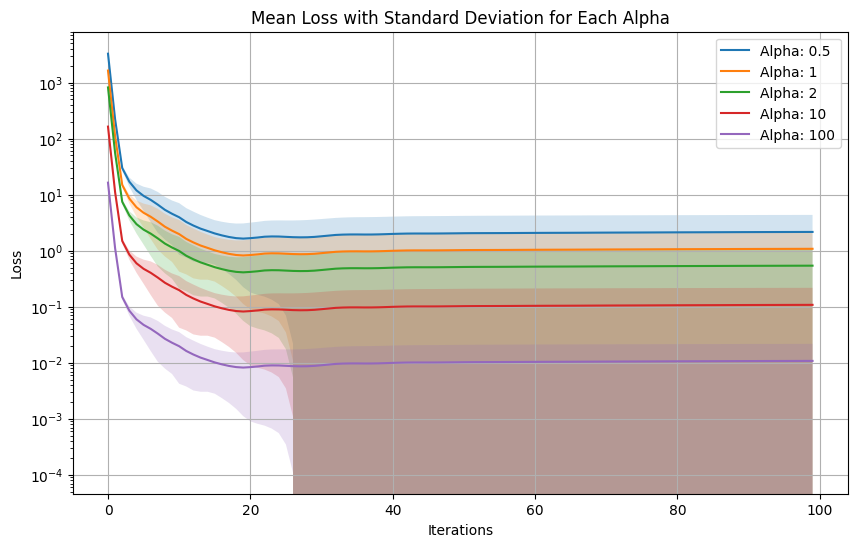

In [6]:
plt.figure(figsize=(10, 6))

for alpha in alpha_list:
    # Convert loss list for the current alpha to a numpy array
    loss_array = np.array(losses[alpha])

    # Calculate mean and standard deviation across iterations
    mean_loss = np.mean(loss_array, axis=1)
    std_loss = np.std(loss_array, axis=1)

    # Get the iterations to plot against (assuming max_iters is 100)
    iterations = np.arange(len(mean_loss))  # This should match with number of iterations

    # Plot the mean loss with standard deviation shading
    plt.plot(iterations, mean_loss, label=f'Alpha: {alpha}')
    plt.fill_between(iterations, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)

# Set y-axis to logarithmic scale
plt.yscale('log')

# Add plot details
plt.title('Mean Loss with Standard Deviation for Each Alpha')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# plt.savefig('mean_loss.pdf', format='pdf')
plt.show()

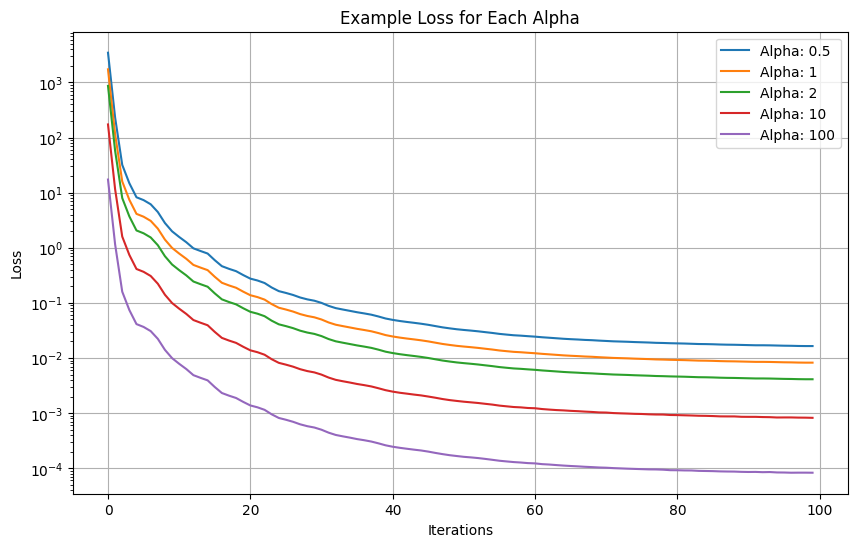

In [7]:
plt.figure(figsize=(10, 6))

for alpha in alpha_list:
    # Convert loss list for the current alpha to a numpy array
    loss_array = np.array(losses[alpha])[:,0]

    # Get the iterations to plot against (assuming max_iters is 100)
    iterations = np.arange(len(loss_array))  # This should match with number of iterations

    # Plot the mean loss with standard deviation shading
    plt.plot(iterations, loss_array, label=f'Alpha: {alpha}')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Add plot details
plt.title('Example Loss for Each Alpha')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# plt.savefig('eg_loss.pdf', format='pdf')
plt.show()

# Visuallize loss

In [44]:
example_batch_index = 0
channel = 100
alpha = 2.0
T = 100
num_iters_to_plot = 10

<Figure size 600x600 with 0 Axes>

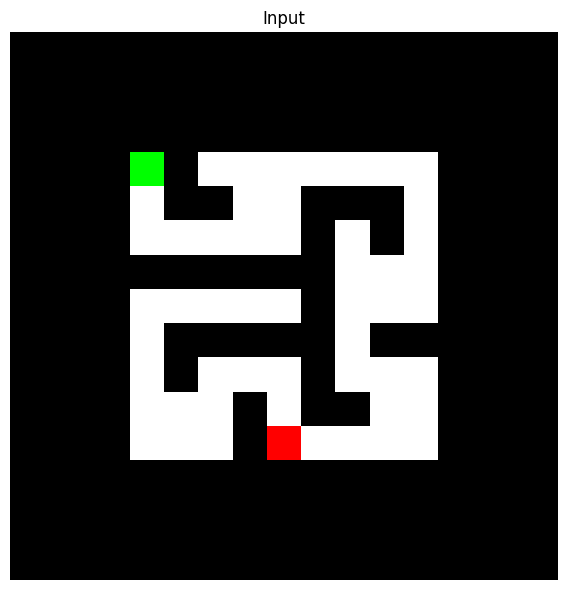

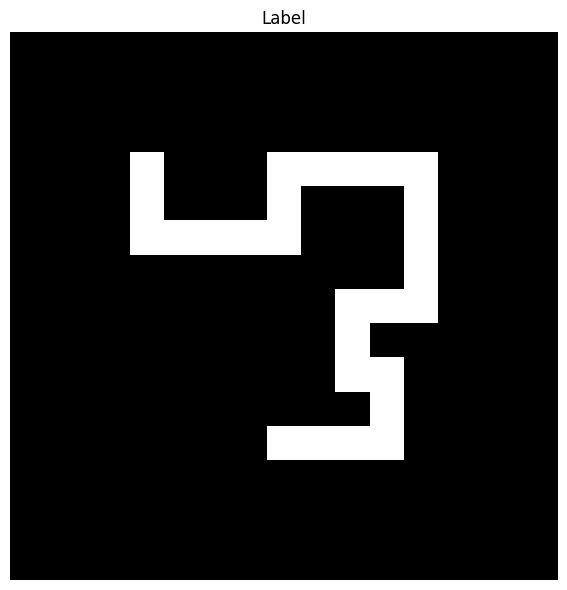

In [32]:
plt.figure(figsize=(6,6))
x_np = np.load('data/maze_data_test_9/inputs.npy')[example_batch_index]
y_np = np.load('data/maze_data_test_9/solutions.npy')[example_batch_index]

plt.figure(figsize=(6, 6))
plt.imshow(x_np, origin='upper', aspect='equal')
plt.title('Input')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(y_np, origin='upper', aspect='equal')
plt.title('Label')
plt.axis('off')
plt.tight_layout()
plt.show()

In [45]:
x = testset[example_batch_index: (example_batch_index + 1)][0].permute(0,3,1,2).to(device)   # batch of 30
# initialize x_5 from projection
x_5 = torch.relu(model.projection(x)).to(device)

snapshots = []
for it in range(T):
    with torch.no_grad():  
        # snapshots for visualization: no grad needed
        x_1 = model.recur_block[0](torch.cat([x_5, x], dim=1))
        conv_x1 = model.recur_block[1][0].conv1(x_1)
        x_21 = torch.relu(conv_x1)
        conv_x21 = model.recur_block[1][0].conv2(x_21)
        x_3 = torch.relu(conv_x21 + x_1)
        conv_x3 = model.recur_block[1][1].conv1(x_3)
        x_41 = torch.relu(conv_x3)
        conv_x41 = model.recur_block[1][1].conv2(x_41)
        x_5 = torch.relu(conv_x41 + x_3)

        t0 = (x_1 - model.recur_block[0](torch.cat([x_5, x], dim=1)))
        t1 = -conv_x1 + x_21
        t2 = -conv_x21 - x_1 + x_3
        t3 = -conv_x3 + x_41
        t4 = -conv_x41 - x_3 + x_5

        s1 = -x_21 + (1.0/alpha) * t1
        s2 = -x_3 + (1.0/alpha) * t2
        s3 = -x_41 + (1.0/alpha) * t3
        s4 = -x_5 + (1.0/alpha) * t4

        relu_s1 = torch.relu(s1)
        relu_s2 = torch.relu(s2)
        relu_s3 = torch.relu(s3)
        relu_s4 = torch.relu(s4)


    # detach and move to cpu numpy arrays for easier plotting later
    snapshots.append({
        'x1': x_1.detach().cpu().numpy().squeeze(0),        # shape (C,H,W)
        'conv_x1': conv_x1.detach().cpu().numpy().squeeze(0),
        'x21': x_21.detach().cpu().numpy().squeeze(0),
        'conv_x21': conv_x21.detach().cpu().numpy().squeeze(0),
        'x3': x_3.detach().cpu().numpy().squeeze(0),
        'conv_x3': conv_x3.detach().cpu().numpy().squeeze(0),
        'x41': x_41.detach().cpu().numpy().squeeze(0),
        'conv_x41': conv_x41.detach().cpu().numpy().squeeze(0),
        'x5': x_5.detach().cpu().numpy().squeeze(0),
        't0': t0.detach().cpu().numpy().squeeze(0),
        't1': t1.detach().cpu().numpy().squeeze(0),
        't2': t2.detach().cpu().numpy().squeeze(0),
        't3': t3.detach().cpu().numpy().squeeze(0),
        't4': t4.detach().cpu().numpy().squeeze(0),
        's1': s1.detach().cpu().numpy().squeeze(0),
        's2': s2.detach().cpu().numpy().squeeze(0),
        's3': s3.detach().cpu().numpy().squeeze(0),
        's4': s4.detach().cpu().numpy().squeeze(0),
        'relu_s1': relu_s1.detach().cpu().numpy().squeeze(0),
        'relu_s2': relu_s2.detach().cpu().numpy().squeeze(0),
        'relu_s3': relu_s3.detach().cpu().numpy().squeeze(0),
        'relu_s4': relu_s4.detach().cpu().numpy().squeeze(0),
    })

print(f"Collected {len(snapshots)} snapshots")

Collected 100 snapshots


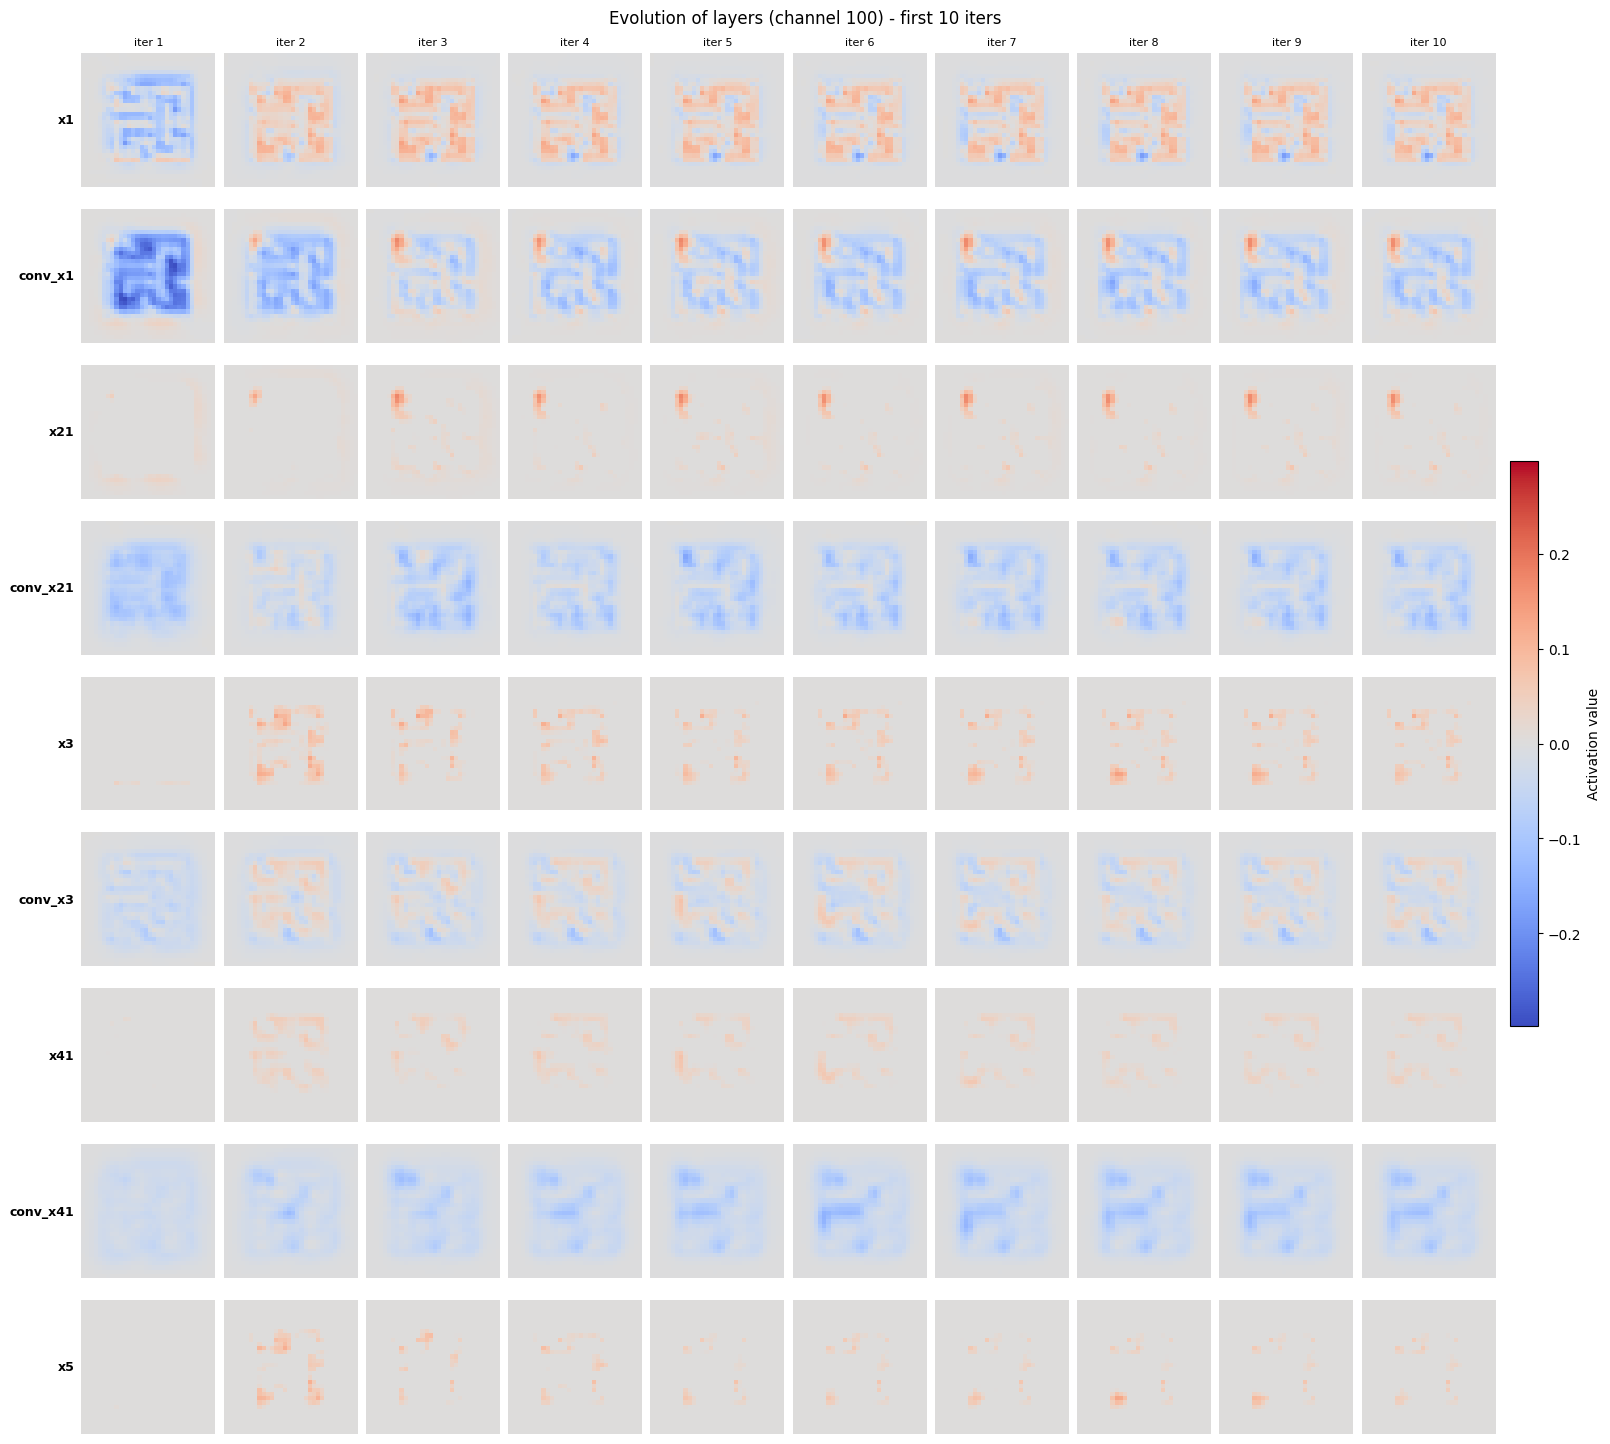

In [46]:
# Plot evolution of layers
keys_row = ['x1','conv_x1','x21','conv_x21','x3','conv_x3','x41','conv_x41','x5']

# rescale all images for plotting
images = []
for key in keys_row:
    frames = [snapshots[i][key][channel] for i in range(1, num_iters_to_plot+1)]
    images.append(np.stack(frames, axis=0))
all_img = np.concatenate(images, axis=0)
vmax = np.abs(all_img).max()
vmin = -vmax

# plot all images
nrows = len(keys_row)
ncols = num_iters_to_plot
fig, axes = plt.subplots(nrows, ncols, figsize=(1.6*ncols, 1.6*nrows), constrained_layout=True)

for r, key in enumerate(keys_row):
    for c in range(ncols):
        ax = axes[r, c] if nrows > 1 else axes[c]
        im = ax.imshow(images[r][c], cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='equal')
        if r == 0:
            ax.set_title(f"iter {c+1}", fontsize=8)
        # hide axis ticks
        ax.set_xticks([])
        ax.set_yticks([])
        # add variable name as left-side text on the first column; also set ylabel for accessibility
        if c == 0:
            # place the label to the left of the image
            ax.text(-0.05, 0.5, key, transform=ax.transAxes, fontsize=9,
                    va='center', ha='right', weight='bold')
            ax.set_ylabel(key, fontsize=8)
        ax.axis('off')

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01, label='Activation value')
plt.suptitle('Evolution of layers (channel {}) - first {} iters'.format(channel, num_iters_to_plot))
plt.show()

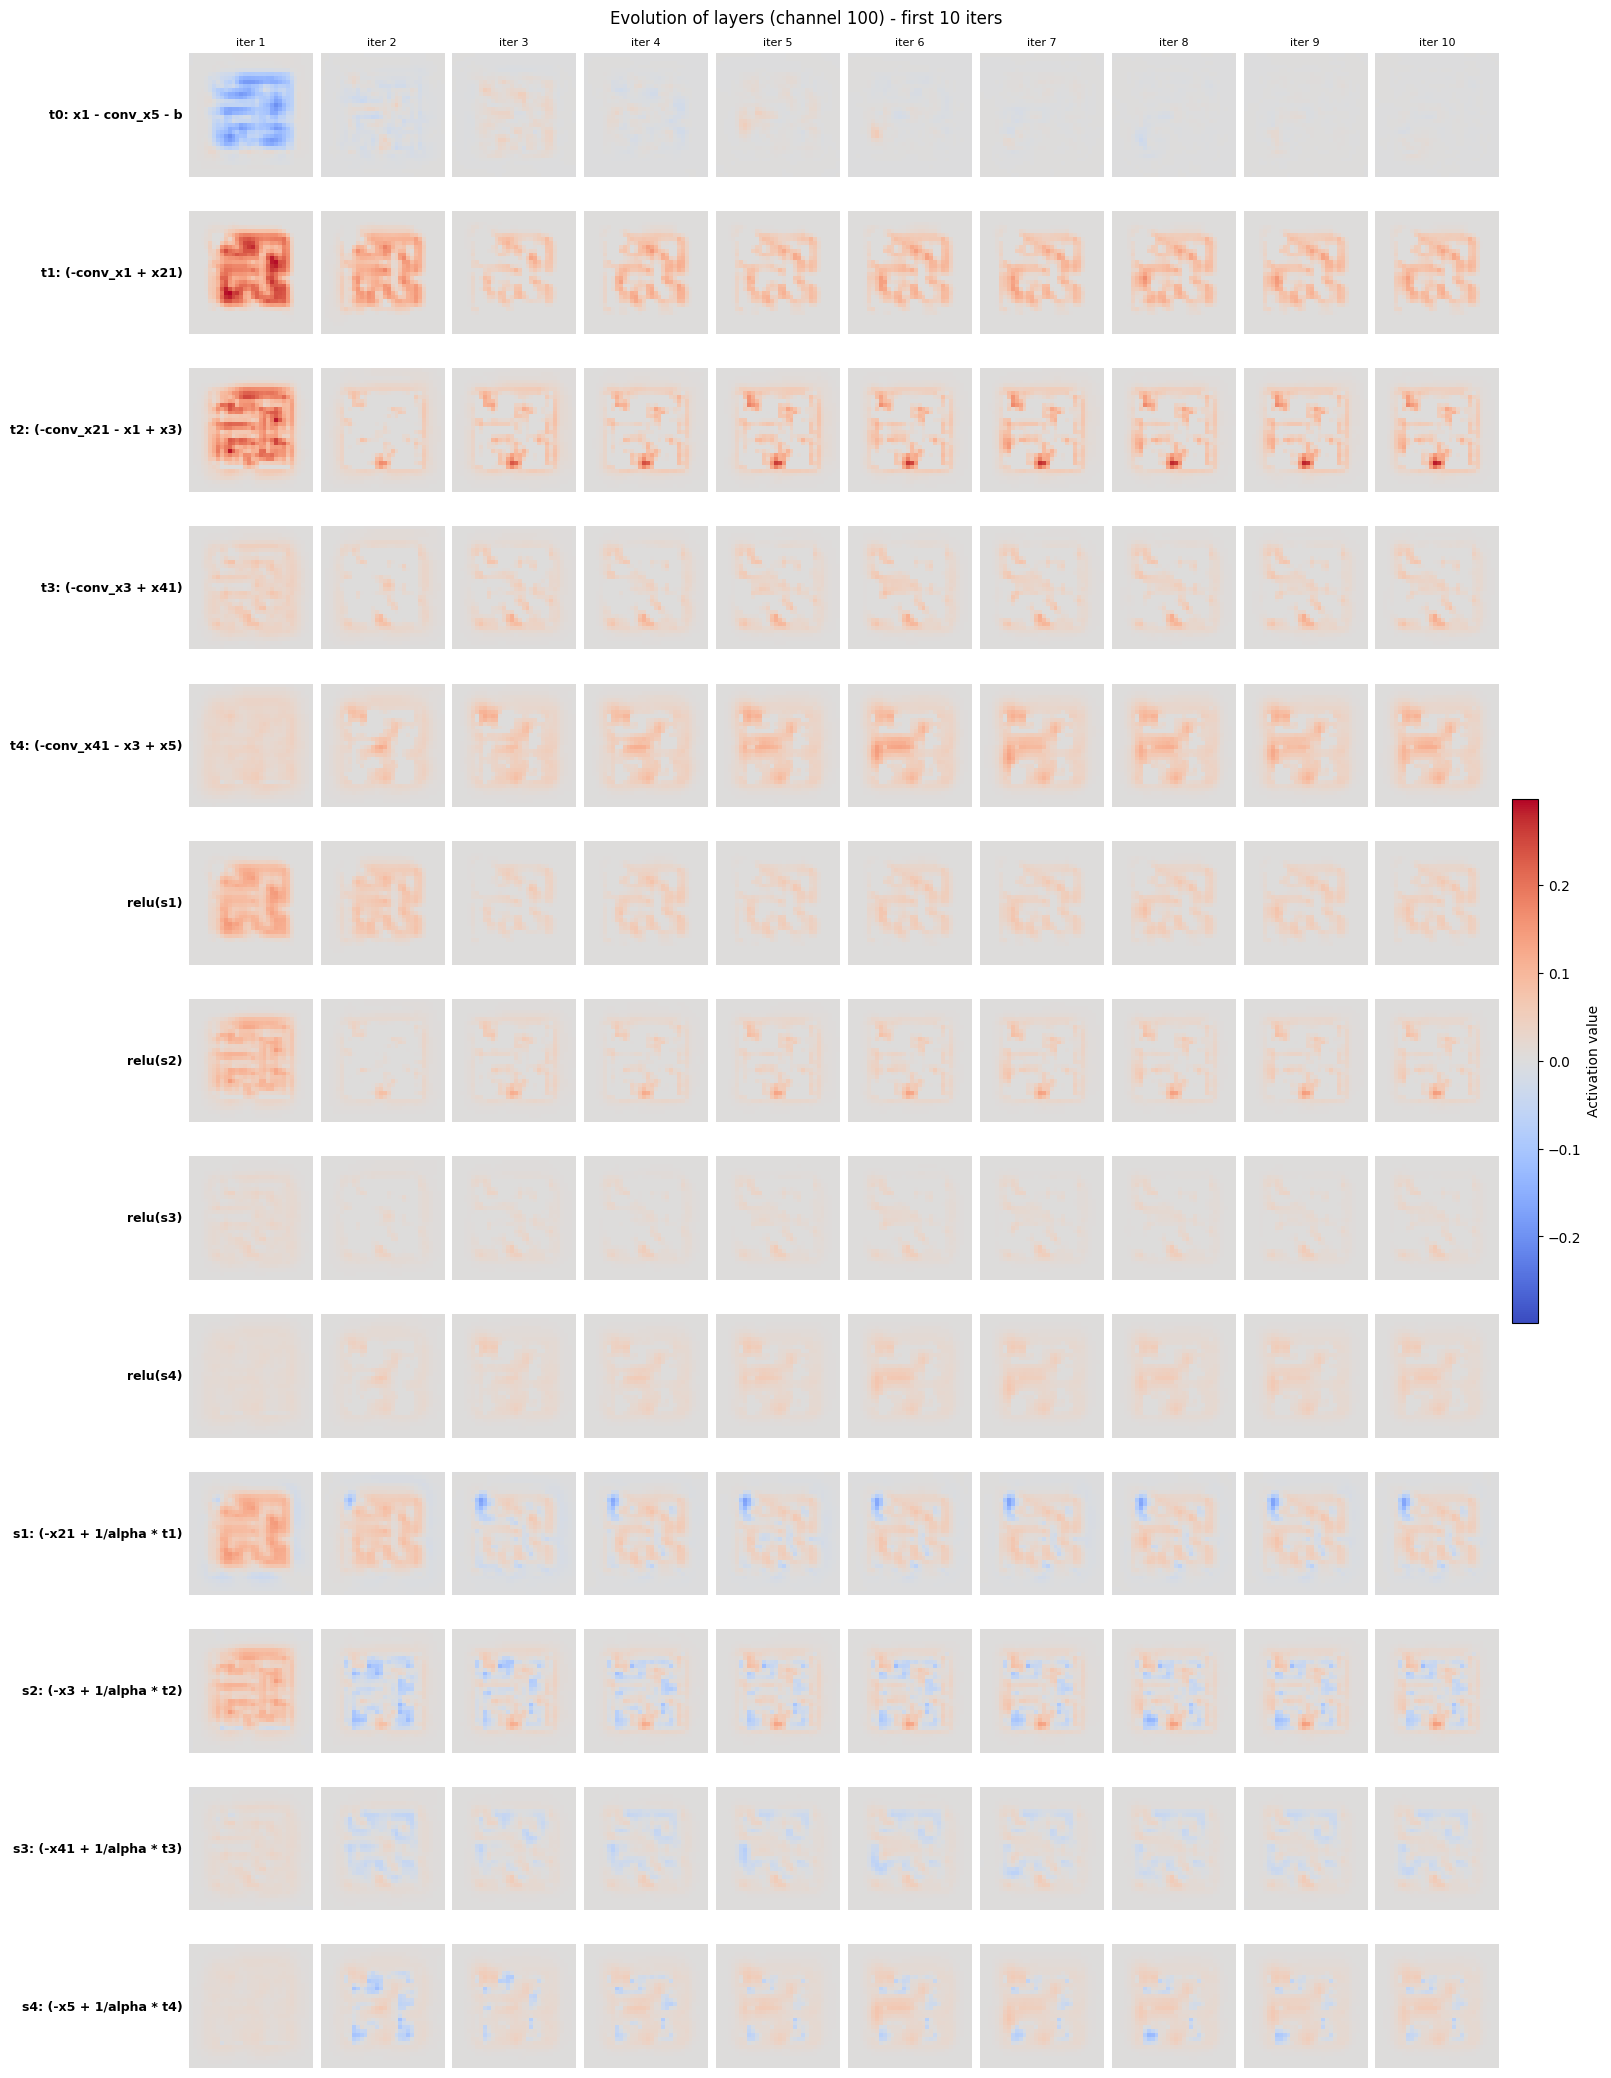

In [47]:
# Compute terms in loss and plot them
term_names = [
    't0: x1 - conv_x5 - b',
    't1: (-conv_x1 + x21)',
    't2: (-conv_x21 - x1 + x3)',
    't3: (-conv_x3 + x41)',
    't4: (-conv_x41 - x3 + x5)',
    'relu(s1)',
    'relu(s2)',
    'relu(s3)',
    'relu(s4)',
    's1: (-x21 + 1/alpha * t1)',    
    's2: (-x3 + 1/alpha * t2)',    
    's3: (-x41 + 1/alpha * t3)',
    's4: (-x5 + 1/alpha * t4)',
]

terms_row = ['t0', 't1', 't2', 't3', 't4', 'relu_s1', 'relu_s2', 'relu_s3', 'relu_s4', 's1', 's2', 's3', 's4']
# rescale all images for plotting
images = []
for key in terms_row:
    frames = [snapshots[i][key][channel] for i in range(1, num_iters_to_plot+1)]
    images.append(np.stack(frames, axis=0))
all_img = np.concatenate(images, axis=0)
vmax = np.abs(all_img).max()
vmin = -vmax

# plot all images
nrows = len(terms_row)
ncols = num_iters_to_plot
fig, axes = plt.subplots(nrows, ncols, figsize=(1.6*ncols, 1.6*nrows), constrained_layout=True)

for r, key in enumerate(terms_row):
    for c in range(ncols):
        ax = axes[r, c] if nrows > 1 else axes[c]
        im = ax.imshow(images[r][c], cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='equal')
        if r == 0:
            ax.set_title(f"iter {c+1}", fontsize=8)
        # hide axis ticks
        ax.set_xticks([])
        ax.set_yticks([])
        # add variable name as left-side text on the first column; also set ylabel for accessibility
        if c == 0:
            # place the label to the left of the image
            ax.text(-0.05, 0.5, term_names[r], transform=ax.transAxes, fontsize=9,
                    va='center', ha='right', weight='bold')
            ax.set_ylabel(term_names[r], fontsize=8)
        ax.axis('off')

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01, label='Activation value')
plt.suptitle('Evolution of layers (channel {}) - first {} iters'.format(channel, num_iters_to_plot))
plt.show()

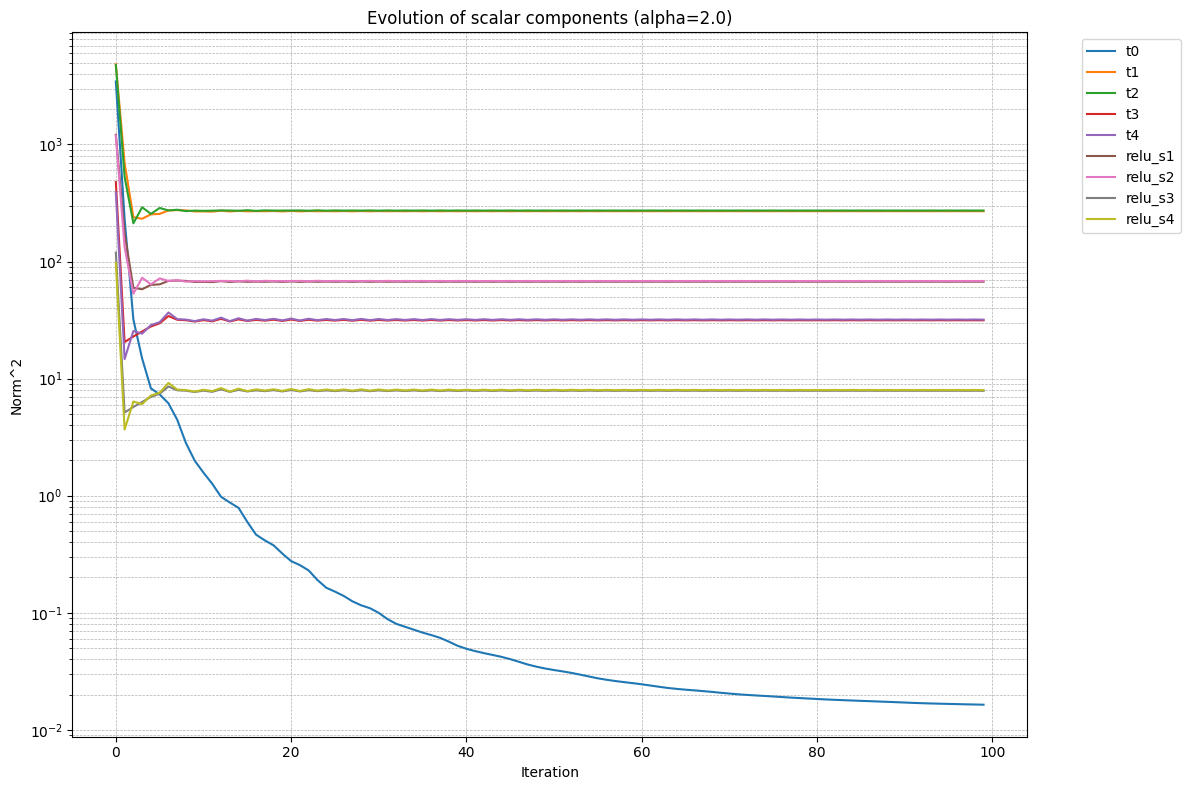

In [48]:
terms_row = ['t0', 't1', 't2', 't3', 't4', 'relu_s1', 'relu_s2', 'relu_s3', 'relu_s4']
term_norm2 = {k: np.zeros(T, dtype=np.float32) for k in terms_row}
for i in range(T):
    for k in terms_row:
        arr = snapshots[i][k]  # numpy array shape (C, H, W)
        # Flatten and compute squared L2 norm
        term_norm2[k][i] = float((arr.ravel() ** 2).sum())

plt.figure(figsize=(12, 8))
iters = np.arange(T)
for r, key in enumerate(terms_row):
    plt.plot(iters, term_norm2[key], label=key)

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Norm^2')
plt.title(f'Evolution of scalar components (alpha={alpha})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

# Visualize kernels

Layer: recur_block.0.weight:  torch.Size([128, 131, 3, 3])


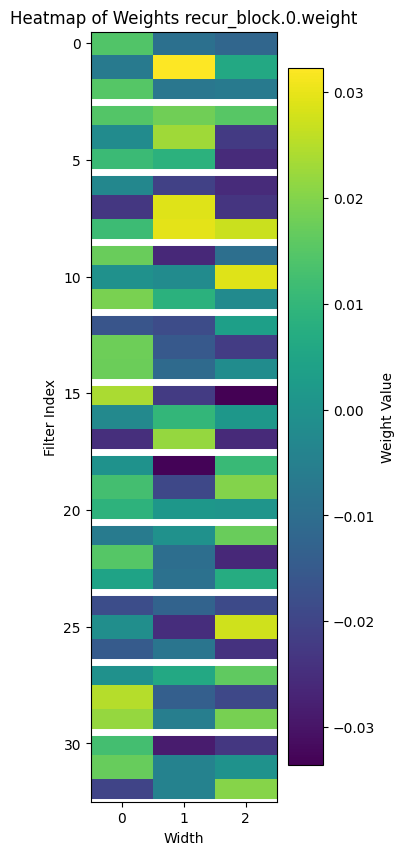

Layer: recur_block.1.0.conv1.weight:  torch.Size([128, 128, 3, 3])


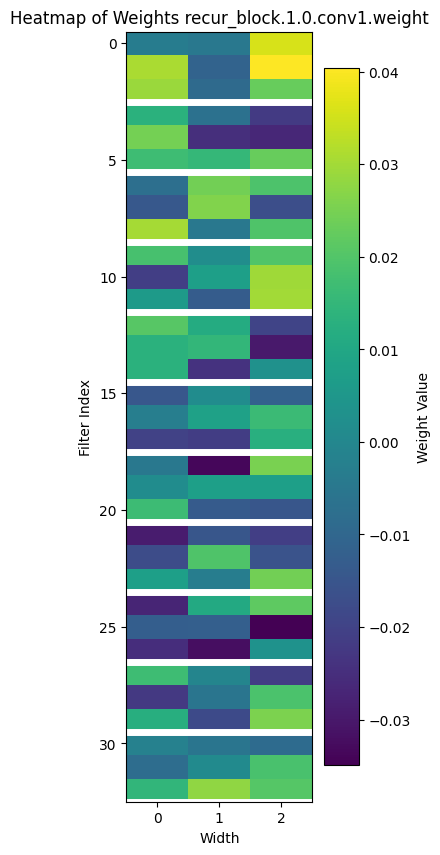

Layer: recur_block.1.0.conv2.weight:  torch.Size([128, 128, 3, 3])


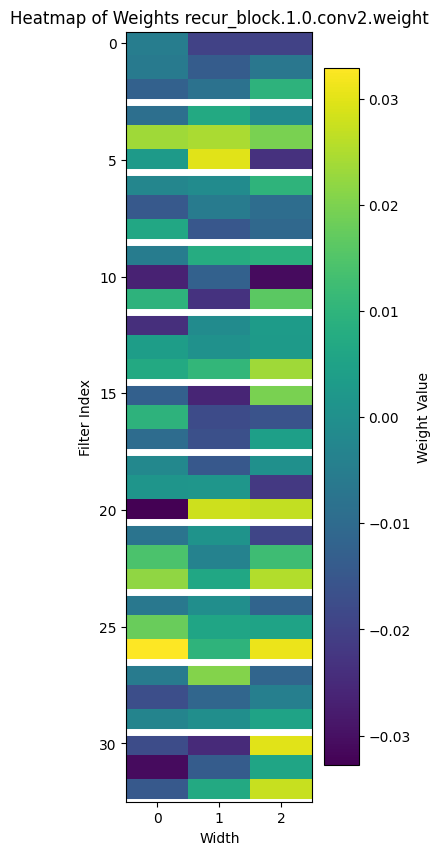

Layer: recur_block.1.1.conv1.weight:  torch.Size([128, 128, 3, 3])


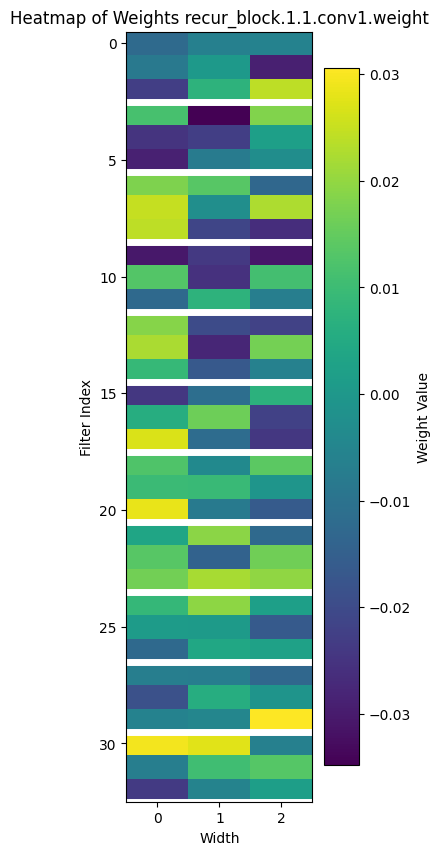

Layer: recur_block.1.1.conv2.weight:  torch.Size([128, 128, 3, 3])


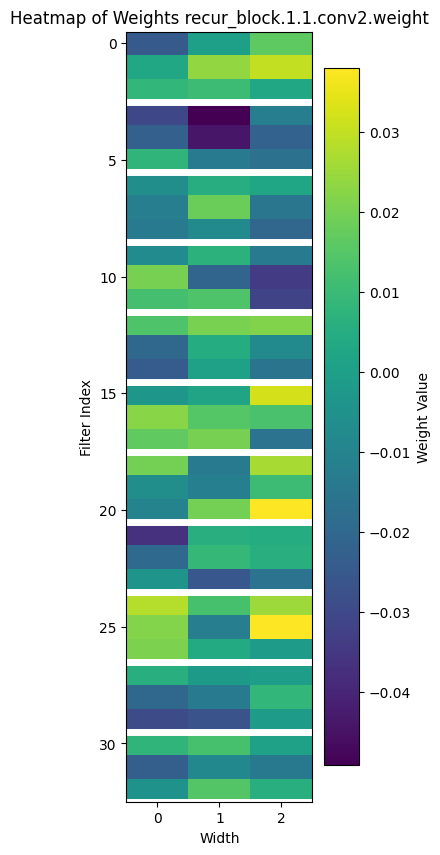

In [13]:
for name, param in new_state_dict.items():
    if 'recur_block' in name:
        print(f"Layer: {name}: ", param.shape)
        
        # Reshape weights for visualization
        weight_visual = param.detach().cpu().numpy()[:, 0, :, :].reshape(-1, 3)

        plt.figure(figsize=(3, 10))
        plt.title(f"Heatmap of Weights {name}")
        # Display heatmap of the weights
        plt.imshow(weight_visual[:33], cmap='viridis', aspect='auto')
        plt.colorbar(label='Weight Value')  # Colour bar to indicate value scale

        num_feature_dims = weight_visual.shape[1]
        plt.xlabel('Width')
        plt.ylabel('Filter Index')
        plt.xticks(ticks=np.arange(num_feature_dims), labels=np.arange(num_feature_dims))

        # Add white bars every three rows
        for i in range(1, 12):  # Adjust the range as needed (for example, 12 can be replaced based on your row count)
            plt.axhline(y=i * 3 - 0.5, color='white', linewidth=5)  # i * 3 - 0.5 controls the placement of the line

        plt.show()